Student: Kevin De Araujo Sanchez
ID: 2022271
CA2 PSI

Github -> https://github.com/2022271-KAS/Problem-Solving-for-Industry---2022

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

*EXPLORATORY PHASE*

In [5]:
dataset = pd.read_excel("online_retail_II.xlsx")

In [7]:
df = dataset.copy()

In [8]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525460,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530.0,United Kingdom


In [10]:
df.shape

(525461, 8)

In [11]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [13]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [14]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [15]:
df.duplicated().sum()

6865

In [16]:
df[df['Quantity'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom
525235,538162,46000M,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


In [17]:
df[df['Price'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.0,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom


In [18]:
df['Description'].value_counts().head(50)

Description
WHITE HANGING HEART T-LIGHT HOLDER    3549
REGENCY CAKESTAND 3 TIER              2212
STRAWBERRY CERAMIC TRINKET BOX        1843
PACK OF 72 RETRO SPOT CAKE CASES      1466
ASSORTED COLOUR BIRD ORNAMENT         1457
60 TEATIME FAIRY CAKE CASES           1400
HOME BUILDING BLOCK WORD              1386
JUMBO BAG RED RETROSPOT               1310
LUNCH BAG RED SPOTTY                  1274
REX CASH+CARRY JUMBO SHOPPER          1232
JUMBO STORAGE BAG SUKI                1220
PACK OF 60 PINK PAISLEY CAKE CASES    1196
WOODEN FRAME ANTIQUE WHITE            1190
LUNCH BAG  BLACK SKULL.               1179
BAKING SET 9 PIECE RETROSPOT          1176
LUNCH BAG SUKI  DESIGN                1157
HEART OF WICKER LARGE                 1151
LOVE BUILDING BLOCK WORD              1142
RED HANGING HEART T-LIGHT HOLDER      1129
SWEETHEART CERAMIC TRINKET BOX        1096
JUMBO SHOPPER VINTAGE RED PAISLEY     1095
JUMBO BAG STRAWBERRY                  1091
HEART OF WICKER SMALL                 1082

In [19]:
df['Revenue'] = df['Quantity'] * df['Price']

In [20]:
df[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


So far I was able to identify some key information about the dataset. The number of columns, rows, data types, mean, min-max values, missing values, duplicated values and also negative values. 
I've create a new feature called Revenue as it will be very useful in the future. 

Next I need to check the duplicated values, as well as the negative ones. I need to find out if the transactions are cancelled or invalid. Clean the invalid transactions and create a few analytical subsets. 

In [21]:
df["is_cancelled_invoice"] = df["Invoice"].astype(str).str.startswith("C")

df["is_negative_quantity"] = df["Quantity"] < 0

df["is_invalid_price"] = df["Price"] <= 0

quality_summary = {
    "total_rows": len(df),
    "duplicates": df.duplicated().sum(),
    "missing_description": df["Description"].isnull().sum(),
    "missing_customer_id": df["Customer ID"].isnull().sum(),
    "cancelled_invoices": df["is_cancelled_invoice"].sum(),
    "negative_quantity_rows": df["is_negative_quantity"].sum(),
    "invalid_price_rows": df["is_invalid_price"].sum()
}

quality_summary

{'total_rows': 525461,
 'duplicates': 6865,
 'missing_description': 2928,
 'missing_customer_id': 107927,
 'cancelled_invoices': 10206,
 'negative_quantity_rows': 12326,
 'invalid_price_rows': 3690}

Next I'll create a clean transactional dataset and drop duplicates, remove rows without product description, keep only positive quantities, keep only valid prices, remove cancelled invoices and calculate revenue after cleaning. 

In [22]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

df_clean = df_clean.dropna(subset=["Description"])

df_clean = df_clean[df_clean["Quantity"] > 0]

df_clean = df_clean[df_clean["Price"] > 0]

df_clean = df_clean[~df_clean["is_cancelled_invoice"]]

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (525461, 12)
Cleaned shape: (504730, 12)


Now that the cleaning is done I don't need these columns anymore. 

In [23]:
df_clean = df_clean.drop(columns=[
    "is_cancelled_invoice",
    "is_negative_quantity",
    "is_invalid_price"
])

Next I'll create a customer-level clean subset to isolate valid customer transactions. It will work for my customer segmentation. I'll also convert customer IDs to integer. 

In [24]:
customer_df = df.dropna(subset=["Customer ID"]).copy()

customer_df["Customer ID"] = customer_df["Customer ID"].astype(int)

print("Customer dataset: ", customer_df.shape)
customer_df.head()

Customer dataset:  (417534, 12)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,is_cancelled_invoice,is_negative_quantity,is_invalid_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,False,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,False,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,False,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,False,False,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,False,False,False


Next is transform raw timestamps into temporal features such as month, weekday, hour and year-month periods.

In [25]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
customer_df["InvoiceDate"] = pd.to_datetime(customer_df["InvoiceDate"])

df["year"] = df["InvoiceDate"].dt.year
df["month"] = df["InvoiceDate"].dt.month
df["year_month"] = df["InvoiceDate"].dt.to_period("M")
df["day_of_week"] = df["InvoiceDate"].dt.day_name()
df["hour"] = df["InvoiceDate"].dt.hour

customer_df["year"] = customer_df["InvoiceDate"].dt.year
customer_df["month"] = customer_df["InvoiceDate"].dt.month
customer_df["year_month"] = customer_df["InvoiceDate"].dt.to_period("M")
customer_df["day_of_week"] = customer_df["InvoiceDate"].dt.day_name()
customer_df["hour"] = customer_df["InvoiceDate"].dt.hour

So far with the data cleaning and preparation stage, many quality validation procedures were done to transform the raw transactional dataset into a reliable analytical dataset. Initially, quality indicators were created to identify cancelled invoices, negative quantities, invalid prices, duplicate rows, and missing values, allowing the project to assess the overall integrity of the data. 

Following all that, a cleaned transactional dataset "df_clean" was created by removing duplicate records, transactions with missing product descriptions, rows containing negative quantities or prices, and cancelled invoices that did not represent valid commercial activity. A revenue feature was created by multiplying quantity by price to support later business analysis. Finally, a customer-level dataset "customer_df" was generated by filtering transactions with valid customer identifiers, creating a dedicated dataset suitable for customer behaviour analysis, RFM feature engineering, and machine learning-based customer segmentation.


Now that I have a clean dataset, I'll have to check everything again and make sure the dataset is in proper shape to be used to accomplish my project objectives. 

In [26]:
df_clean.shape

(504730, 9)

In [27]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504730 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      504730 non-null  object        
 1   StockCode    504730 non-null  object        
 2   Description  504730 non-null  object        
 3   Quantity     504730 non-null  int64         
 4   InvoiceDate  504730 non-null  datetime64[ns]
 5   Price        504730 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      504730 non-null  object        
 8   Revenue      504730 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 38.5+ MB


In [28]:
df_clean.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,504730.000000,504730,504730.000000,400916.000000,504730.000000
mean,11.516944,2010-06-28 17:28:36.218374144,4.273960,15361.544074,20.351005
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,1.000000,2010-03-21 14:06:15,1.250000,13985.000000,4.200000
50%,3.000000,2010-07-06 14:25:00,2.100000,15311.000000,10.200000
75%,12.000000,2010-10-15 13:37:00,4.210000,16805.000000,17.700000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,25111.090000
std,87.337583,NaN,64.091288,1680.635823,91.509716


In [29]:
df_clean.isnull().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    103814
Country             0
Revenue             0
dtype: int64

The cleaned dataset seems to be good for product and transaction level as well as basket analysis. However, there a lot of missing values to be dealt with and also some extreme values to be further investigated. 
Next I'll create a business overview of the cleaned dataset before a deeper EDA to visualize better what's going on. 

In [30]:
total_revenue = df_clean["Revenue"].sum()
total_quantity = df_clean["Quantity"].sum()
total_invoices = df_clean["Invoice"].nunique()
unique_products = df_clean["StockCode"].nunique()
unique_customers = df_clean["Customer ID"].nunique()
unique_countries = df_clean["Country"].nunique()

print("Total revenue:", round(total_revenue, 2))
print("Total quantity sold:", total_quantity)
print("Total invoices:", total_invoices)
print("Unique products:", unique_products)
print("Unique customers:", unique_customers)
print("Countries:", unique_countries)

Total revenue: 10271762.66
Total quantity sold: 5812947
Total invoices: 20951
Unique products: 4251
Unique customers: 4312
Countries: 40


In [31]:
business_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Invoices",
        "Unique Products",
        "Unique Customers",
        "Countries"
    ],
    "Value": [
        round(total_revenue, 2),
        total_quantity,
        total_invoices,
        unique_products,
        unique_customers,
        unique_countries
    ]
})

business_summary

,Metric,Value
0,Total Revenue,10271762.66
1,Total Quantity Sold,5812947.00
2,Total Invoices,20951.00
3,Unique Products,4251.00
4,Unique Customers,4312.00
5,Countries,40.00


So far it's verifiable that the dataset contains over 10.27 million pounds in revenue, loads of transactional volume for business analysis. 
More than 5.8 milion items were sold across 20,951 invoices, large transactional activity. 
More than 4k200 unique products. 
The dataset contains 4,312 identifiable customers over 40 countries. 

The dataset is large and with good volume to support customer segmentation and association rule analysis. 
Skewness needs to be further investigated, some products seem to dominate sales while many products are not usually bought. It can future impact product optimisation, recommendation logic and cluster interpretation. 

Next I'll check monthly results, look for seasonality and operational trends. 

In [32]:
monthly_revenue = df_clean.groupby(
    df_clean["InvoiceDate"].dt.to_period("M")
)["Revenue"].sum()

monthly_revenue

InvoiceDate
2009-12     822483.950
2010-01     651155.112
2010-02     551504.726
2010-03     830915.261
2010-04     678875.252
2010-05     657705.500
2010-06     749537.310
2010-07     648810.270
2010-08     695251.910
2010-09     921696.991
2010-10    1161902.220
2010-11    1464293.142
2010-12     437631.020
Freq: M, Name: Revenue, dtype: float64

<Axes: title={'center': 'Monthly Revenue'}, xlabel='InvoiceDate'>

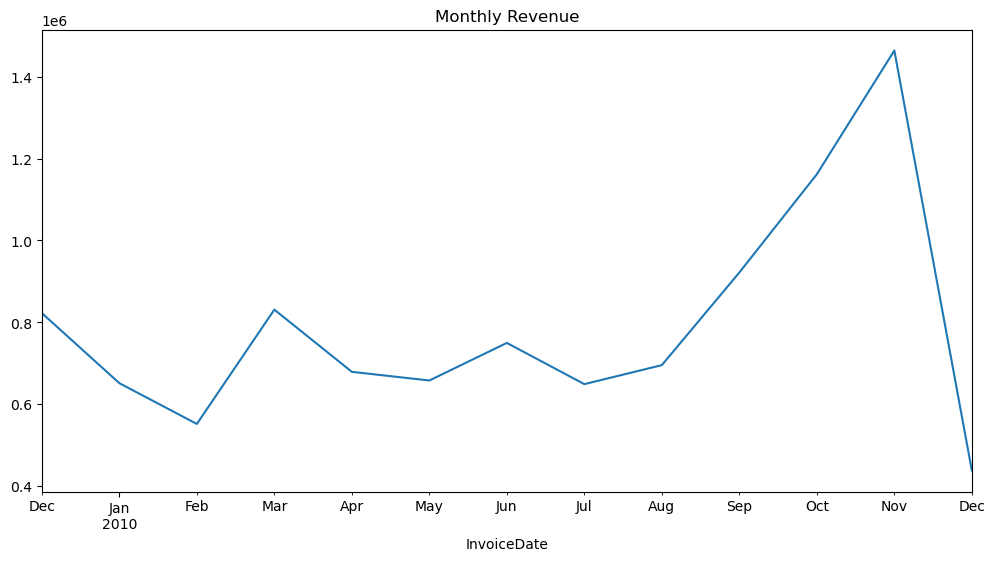

In [33]:
monthly_revenue.plot(
    figsize=(12,6),
    title="Monthly Revenue"
)

This revenue analysis shows that revenue increased a lot in the final quarter of the year, the peak at November. But, it's worth mentioning that the data is incomplete, as the dataset only includes transactions until 9 December 2010. That was one of the reasons I gave up on forecasting. But, in the end, it shows some time based pattern. 

Next I'll check monthly quantity sold and monthly invoice count against revenue to find some sort of relationship. 

In [34]:
monthly_quantity = df_clean.groupby(
    df_clean["InvoiceDate"].dt.to_period("M")
)["Quantity"].sum()

monthly_quantity

InvoiceDate
2009-12    425461
2010-01    390672
2010-02    381879
2010-03    526026
2010-04    366705
2010-05    395868
2010-06    406820
2010-07    337895
2010-08    472380
2010-09    583864
2010-10    619996
2010-11    725161
2010-12    180220
Freq: M, Name: Quantity, dtype: int64

<Axes: title={'center': 'Monthly Quantity Sold'}, xlabel='InvoiceDate'>

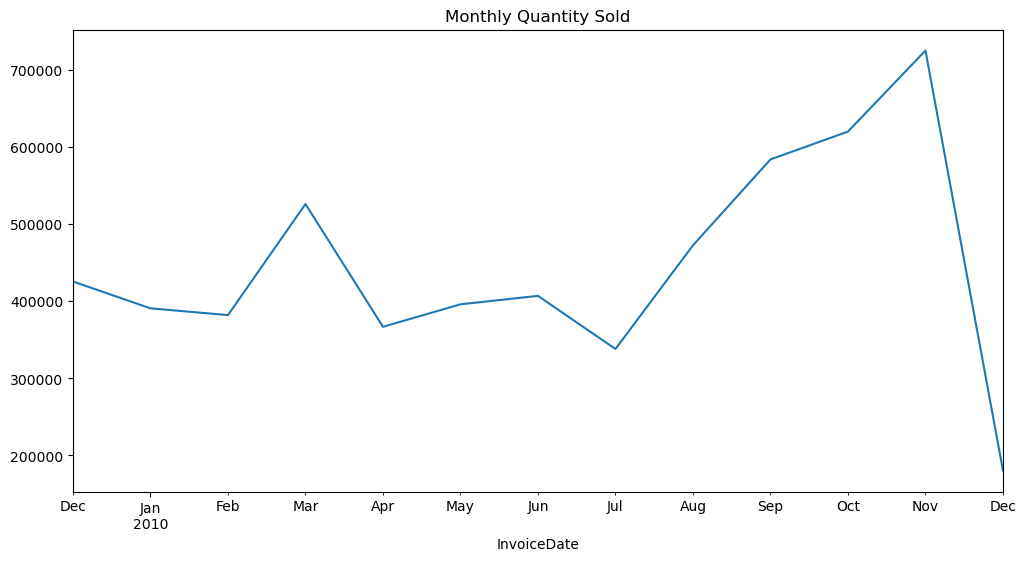

In [35]:
monthly_quantity.plot(
    figsize=(12,6),
    title="Monthly Quantity Sold"
)

In [36]:
monthly_invoices = df_clean.groupby(
    df_clean["InvoiceDate"].dt.to_period("M")
)["Invoice"].nunique()

monthly_invoices

InvoiceDate
2009-12    1682
2010-01    1105
2010-02    1201
2010-03    1681
2010-04    1462
2010-05    1500
2010-06    1645
2010-07    1529
2010-08    1425
2010-09    1839
2010-10    2301
2010-11    2747
2010-12     834
Freq: M, Name: Invoice, dtype: int64

<Axes: title={'center': 'Monthly Number of Invoices'}, xlabel='InvoiceDate'>

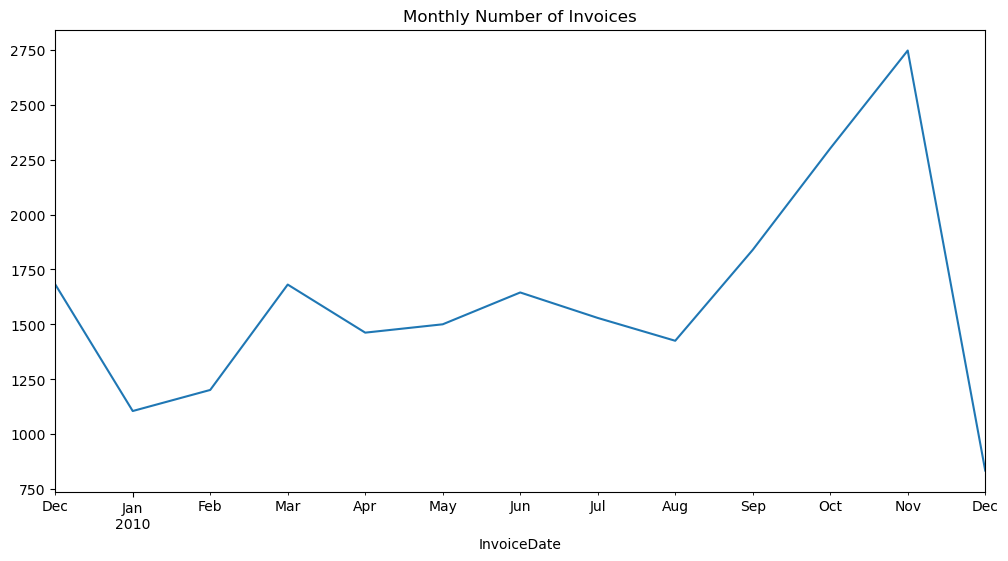

In [37]:
monthly_invoices.plot(
    figsize=(12,6),
    title="Monthly Number of Invoices"
)

The time based exploration showed a pretty consistent result, it proves the pattern is consistent. Monthly revenue, quantity sold, and invoice count all rise in volume from September to November 2010. This means the revenue increase is not random. 
November is the strongest month in the dataset with a revenue of £1.46m, 725,161 items sold and 2,747 invoices generated. December should probably hit the highest peak due to Christmas but the dataset doesn't have the data. 
The result is a clear seasonal intensity in the dataset. 

Next products performance exploration. I'll start with a product performance table.

In [38]:
product_performance = df_clean.groupby(["StockCode", "Description"]).agg(
    total_revenue=("Revenue", "sum"),
    total_quantity=("Quantity","sum"),
    invoice_count=("Invoice", "nunique"),
    average_price=("Price", "mean")
)
product_performance.head()

,,total_revenue,total_quantity,invoice_count,average_price
StockCode,Description,,,,
10002,INFLATABLE POLITICAL GLOBE,6333.76,7971,310,0.967714
10080,GROOVY CACTUS INFLATABLE,10.20,12,5,0.850000
10109,BENDY COLOUR PENCILS,1.68,4,1,0.420000
10120,DOGGY RUBBER,105.57,487,47,0.256809
10125,MINI FUNKY DESIGN TAPES,761.66,853,81,1.012941


In [39]:
top_revenue_products = product_performance.sort_values(
    by="total_revenue",
    ascending=False
).head(10)

top_revenue_products

,,total_revenue,total_quantity,invoice_count,average_price
StockCode,Description,,,,
M,Manual,262577.36,2764,512,473.651382
22423,REGENCY CAKESTAND 3 TIER,169912.76,13685,2019,14.378958
85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281,3.048492
DOT,DOTCOM POSTAGE,116408.71,730,730,159.463986
84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412,1.995819
22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30,17205,957,3.367165
85099B,JUMBO BAG RED RETROSPOT,54368.82,30327,1222,2.169936
47566,PARTY BUNTING,49664.12,10079,1013,5.610272
POST,POSTAGE,49477.54,2310,759,26.655191


In [40]:
top_quantity_products = product_performance.sort_values(
    by="total_quantity",
    ascending=False
).head(10)

top_quantity_products

,,total_revenue,total_quantity,invoice_count,average_price
StockCode,Description,,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281,3.048492
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,11383.97,54947,501,0.244016
17003,BROCADE RING PURSE,8922.80,48374,230,0.240513
21212,PACK OF 72 RETRO SPOT CAKE CASES,24054.43,46728,1410,0.665916
84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412,1.995819
84991,60 TEATIME FAIRY CAKE CASES,18151.40,36348,1336,0.651815
21977,PACK OF 60 PINK PAISLEY CAKE CASES,16187.31,31805,1155,0.690638
85099B,JUMBO BAG RED RETROSPOT,54368.82,30327,1222,2.169936
22197,SMALL POPCORN HOLDER,27022.23,29773,882,1.019145


In [41]:
top_frequency_products = product_performance.sort_values(
    by="invoice_count",
    ascending=False
).head(10)

top_frequency_products

,,total_revenue,total_quantity,invoice_count,average_price
StockCode,Description,,,,
85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281,3.048492
22423,REGENCY CAKESTAND 3 TIER,169912.76,13685,2019,14.378958
21232,STRAWBERRY CERAMIC TRINKET BOX,34411.68,27059,1640,1.465954
84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412,1.995819
21212,PACK OF 72 RETRO SPOT CAKE CASES,24054.43,46728,1410,0.665916
84991,60 TEATIME FAIRY CAKE CASES,18151.40,36348,1336,0.651815
21754,HOME BUILDING BLOCK WORD,30851.27,5037,1331,6.577502
85099B,JUMBO BAG RED RETROSPOT,54368.82,30327,1222,2.169936
20725,LUNCH BAG RED SPOTTY,29773.27,17885,1218,1.961779


In [42]:
slow_moving_products = product_performance.sort_values(
    by="invoice_count",
    ascending=True
).head(10)

slow_moving_products

,,total_revenue,total_quantity,invoice_count,average_price
StockCode,Description,,,,
90004A,JADE GREEN PAIR ENAMEL HAIR SLIDES,3.75,1,1,3.75
84760L,LARGE HANGING GLASS+ZINC LANTERN,896.00,560,1,1.60
85159b,"WHITE TEA,COFFEE,SUGAR JARS",13.00,1,1,13.00
21290,LARGE SPOTTY CHOCOLATE GIFT BAG,2.50,2,1,1.25
85049g,CHOCOLATE BOX RIBBONS,5.02,2,1,2.51
84402B,PURPLE DRESS JEWELLERY STAND,2.95,1,1,2.95
85049b,LUSH GREENS RIBBONS,5.02,2,1,2.51
35751D,PINK CURRENT CANDLE RING,5.32,28,1,0.19
22343,PARTY PIZZA DISH RED+WHITE SPOT,10.20,12,1,0.85


StockCode has some noise coming from POST, DOT, M and gift (probably vouchers). They're codes not actual retail products. I'll exclude them and re-run the sorting of products otherwise they can distort results of product ranking and recommendation analysis. 

In [43]:
product_perf_clean = product_performance.reset_index()

product_perf_clean = product_perf_clean[
    ~product_perf_clean["StockCode"].isin(["POST", "DOT", "M", "m"])
]

product_perf_clean = product_perf_clean[
    ~product_perf_clean["StockCode"].astype(str).str.startswith("gift_")
]

product_perf_clean.head()

,StockCode,Description,total_revenue,total_quantity,invoice_count,average_price
0,10002,INFLATABLE POLITICAL GLOBE,6333.76,7971,310,0.967714
1,10080,GROOVY CACTUS INFLATABLE,10.20,12,5,0.850000
2,10109,BENDY COLOUR PENCILS,1.68,4,1,0.420000
3,10120,DOGGY RUBBER,105.57,487,47,0.256809
4,10125,MINI FUNKY DESIGN TAPES,761.66,853,81,1.012941


In [44]:
top_revenue_products = product_perf_clean.sort_values(
    by="total_revenue",
    ascending=False
).head(10)
top_revenue_products

,StockCode,Description,total_revenue,total_quantity,invoice_count,average_price
1731,22423,REGENCY CAKESTAND 3 TIER,169912.76,13685,2019,14.378958
4271,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281,3.048492
2892,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412,1.995819
1330,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30,17205,957,3.367165
4254,85099B,JUMBO BAG RED RETROSPOT,54368.82,30327,1222,2.169936
2556,47566,PARTY BUNTING,49664.12,10079,1013,5.610272
2738,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49,23037,347,3.267682
3169,15056N,EDWARDIAN PARASOL NATURAL,36251.10,7416,591,6.717601
920,21621,VINTAGE UNION JACK BUNTING,36023.71,4144,829,9.215887
4258,85099F,JUMBO BAG STRAWBERRY,35887.14,19835,1040,2.229659


<Axes: title={'center': 'Top 10 Products by Revenue'}, ylabel='Description'>

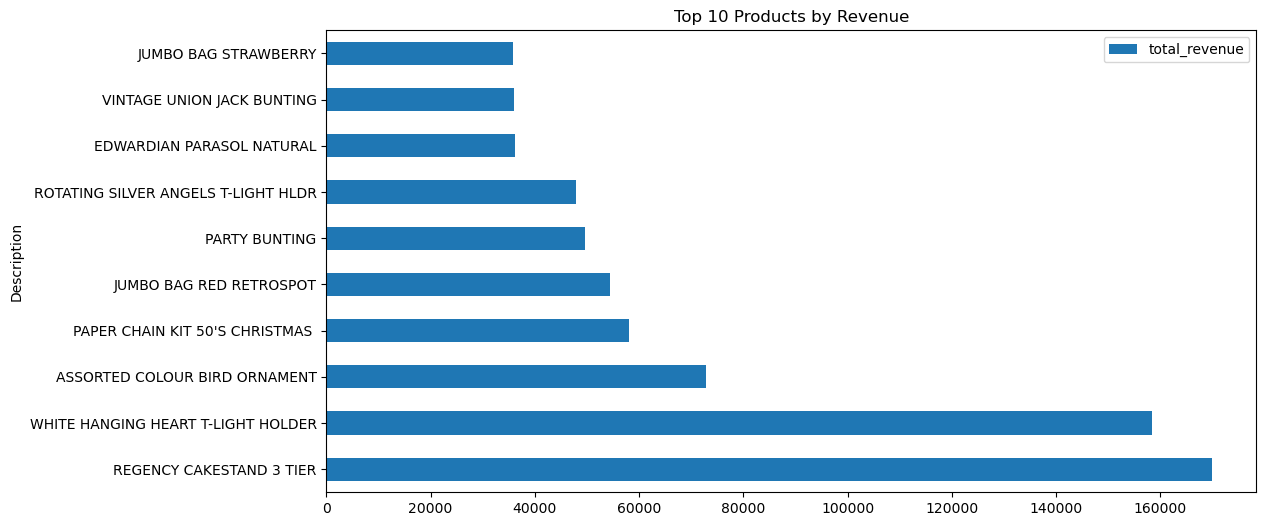

In [101]:
top_revenue_products = product_perf_clean.sort_values(
    by="total_revenue",
    ascending=False
).head(10)

top_revenue_products.plot(
    kind="barh",
    x="Description",
    y="total_revenue",
    figsize=(12,6),
    title="Top 10 Products by Revenue"
)

In [45]:
top_quantity_products = product_perf_clean.sort_values(
    by="total_quantity",
    ascending=False
).head(10)

top_quantity_products

,StockCode,Description,total_revenue,total_quantity,invoice_count,average_price
4271,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281,3.048492
2722,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,11383.97,54947,501,0.244016
52,17003,BROCADE RING PURSE,8922.80,48374,230,0.240513
533,21212,PACK OF 72 RETRO SPOT CAKE CASES,24054.43,46728,1410,0.665916
2892,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412,1.995819
2938,84991,60 TEATIME FAIRY CAKE CASES,18151.40,36348,1336,0.651815
1238,21977,PACK OF 60 PINK PAISLEY CAKE CASES,16187.31,31805,1155,0.690638
4254,85099B,JUMBO BAG RED RETROSPOT,54368.82,30327,1222,2.169936
1455,22197,SMALL POPCORN HOLDER,27022.23,29773,882,1.019145
554,21232,STRAWBERRY CERAMIC TRINKET BOX,34411.68,27059,1640,1.465954


<Axes: title={'center': 'Top 10 Products by Quantity Sold'}, ylabel='Description'>

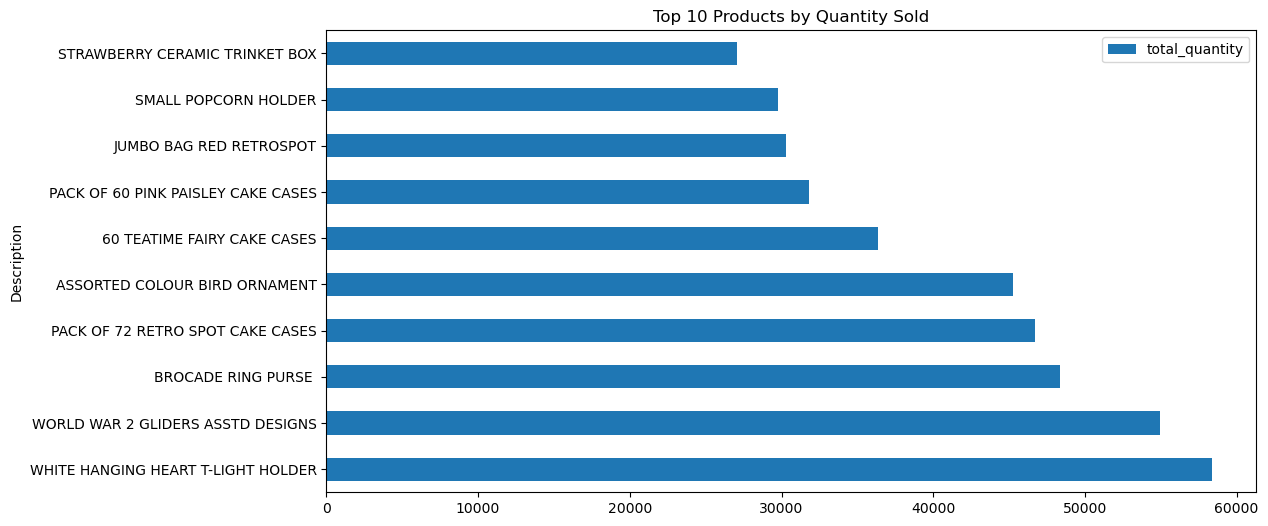

In [103]:
top_quantity_products = product_perf_clean.sort_values(
    by="total_quantity",
    ascending=False
).head(10)

top_quantity_products.plot(
    kind="barh",
    x="Description",
    y="total_quantity",
    figsize=(12,6),
    title="Top 10 Products by Quantity Sold"
)

In [46]:
top_frequency_products = product_perf_clean.sort_values(
    by="invoice_count",
    ascending=False
).head(10)

top_frequency_products

,StockCode,Description,total_revenue,total_quantity,invoice_count,average_price
4271,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72,58386,3281,3.048492
1731,22423,REGENCY CAKESTAND 3 TIER,169912.76,13685,2019,14.378958
554,21232,STRAWBERRY CERAMIC TRINKET BOX,34411.68,27059,1640,1.465954
2892,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19,45228,1412,1.995819
533,21212,PACK OF 72 RETRO SPOT CAKE CASES,24054.43,46728,1410,0.665916
2938,84991,60 TEATIME FAIRY CAKE CASES,18151.40,36348,1336,0.651815
1056,21754,HOME BUILDING BLOCK WORD,30851.27,5037,1331,6.577502
4254,85099B,JUMBO BAG RED RETROSPOT,54368.82,30327,1222,2.169936
151,20725,LUNCH BAG RED SPOTTY,29773.27,17885,1218,1.961779
1211,21931,JUMBO STORAGE BAG SUKI,31493.71,15838,1179,2.321065


Key findings about the products are: REGENCY CAKESTAND 3 TIER is the highest revenue product at £169,912.76. 
WHITE HANGING HEART T-LIGHT HOLDER is the strongest overall item because it ranks as the 2nd by revenue, 1st by quantity sold and 1st by invoice frequency. 
Some products are high volyme but low value, such as WORLD WAR 2 GLIDERS ASSTD DESIGNS. 
Product performance is different depending on the metric used. 
-Revenue shows financial importance.
-Quantity shows volume demand.
-Invoice frequency shows repeated purchases. 

After this product analysis I can state that the product value can't be judged using a single metric. Some products generate high revenue because of higher unit price, on the other hand others dominate because of high sales volume or frequency across invoices. This supports the need for a multi-dimensional product analysis when making menu, stock or upselling decisions. 

Next I'll explore customer behaviour in the dataset. This will help to justify segmentation. I'll start by creating a customer behaviour table. 

In [47]:
customer_df = df_clean.dropna(subset=["Customer ID"]).copy()

customer_df["Customer ID"] = customer_df["Customer ID"].astype(int)

customer_behaviour = customer_df.groupby("Customer ID").agg(
    total_revenue=("Revenue", "sum"),
    total_quantity=("Quantity", "sum"),
    invoice_count=("Invoice", "nunique"),
    unique_products=("StockCode", "nunique"),
    average_order_values=("Revenue", "mean")
).reset_index()

customer_behaviour.head()

,Customer ID,total_revenue,total_quantity,invoice_count,unique_products,average_order_values
0,12346,372.86,70,11,26,11.298788
1,12347,1323.32,828,2,70,18.638310
2,12348,222.16,373,1,20,11.108000
3,12349,2671.14,993,3,90,26.187647
4,12351,300.93,261,1,21,14.330000


In [48]:
customer_behaviour.describe()

,Customer ID,total_revenue,total_quantity,invoice_count,unique_products,average_order_values
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,2040.406712,1280.050557,4.455705,63.646104,37.009327
std,1701.200176,8911.755977,6457.926351,8.170213,85.757966,217.715476
min,12346.000000,2.950000,1.000000,1.000000,1.000000,1.993684
25%,13882.500000,307.187500,156.000000,1.000000,17.000000,11.193531
50%,15350.500000,701.615000,380.000000,2.000000,38.000000,17.361560
75%,16834.250000,1714.932500,992.000000,5.000000,79.250000,24.839503
max,18287.000000,349164.350000,220600.000000,205.000000,1741.000000,10953.500000


In [49]:
top_customers_revenue = customer_behaviour.sort_values(
    by="total_revenue",
    ascending=False
).head(10)

top_customers_revenue

,Customer ID,total_revenue,total_quantity,invoice_count,unique_products,average_order_values
4183,18102,349164.35,124216,89,281,556.880941
1637,14646,248396.50,170278,78,606,140.099549
1269,14156,196549.74,108105,102,1094,74.281837
1840,14911,152121.22,69709,205,1741,27.320621
939,13694,131443.19,125893,94,654,137.349206
3744,17511,84541.17,55107,31,423,89.178449
1951,15061,83284.38,51791,86,116,142.610240
3128,16684,80489.21,54555,27,124,182.515215
3177,16754,65500.07,63551,29,38,467.857643
4065,17949,60117.60,30112,74,34,691.006897


In [50]:
top_customers_frequency = customer_behaviour.sort_values(
    by="invoice_count",
    ascending=False
).head(10)

top_customers_frequency

,Customer ID,total_revenue,total_quantity,invoice_count,unique_products,average_order_values
1840,14911,152121.22,69709,205,1741,27.320621
3996,17850,51208.87,21052,155,100,20.491745
251,12748,22457.90,13109,144,1342,8.873133
2133,15311,55942.74,32784,121,594,27.449823
506,13089,57885.45,29125,109,474,37.539202
1606,14606,18482.10,9287,102,1086,4.861152
1269,14156,196549.74,108105,102,1094,74.281837
939,13694,131443.19,125893,94,654,137.349206
3989,17841,29562.02,14332,91,1509,5.979373
4183,18102,349164.35,124216,89,281,556.880941


<Axes: >

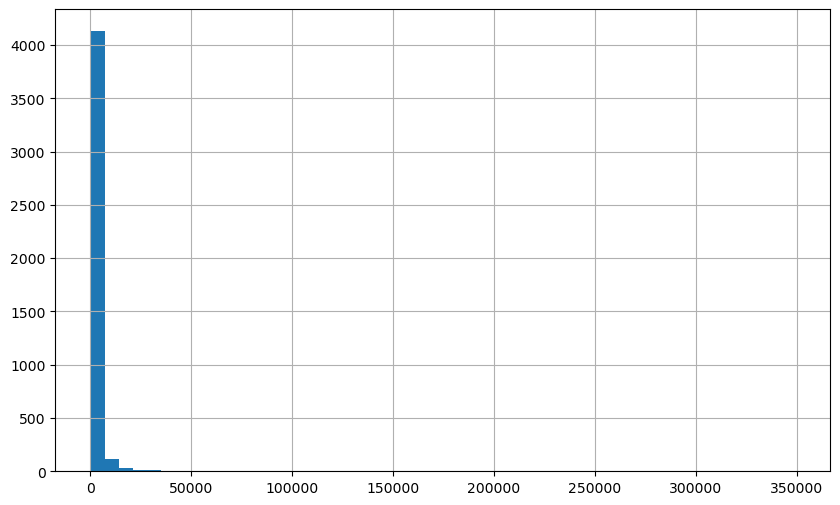

In [51]:
customer_behaviour["total_revenue"].hist(
    figsize=(10,6),
    bins=50
)

Some of the key findings are: Customer behaviour is highly skewed, as per the histogram. Most customers spend relatively little, while a small number of customers spend and generate high revenue. To prove that we just need to check the average customer revenue: £2,040. median customer revenue: £701. maximum customer revenue: £349,164. 

There's a huge gap that proves inequality between customer purchases. This indicates that the customer base is not equal and supports the use of clustering techniques like K-Means to segment customers based on behavioural patterns. 

Next I'll analyze Invoice behaviour.  

In [54]:
invoice_behaviour = df_clean.groupby("Invoice").agg(
    invoice_value=("Revenue", "sum"),
    total_quantity=("Quantity", "sum"),
    unique_products=("StockCode", "nunique"),
    total_lines=("StockCode", "count")
).reset_index()

invoice_behaviour.head()

,Invoice,invoice_value,total_quantity,unique_products,total_lines
0,489434,505.30,166,8,8
1,489435,145.80,60,4,4
2,489436,630.33,193,19,19
3,489437,310.75,145,23,23
4,489438,2286.24,826,17,17


In [55]:
invoice_behaviour.describe()

,Invoice,invoice_value,total_quantity,unique_products,total_lines
count,20951.000000,20951.000000,20951.000000,20951.000000,20951.000000
mean,514296.684406,490.275532,277.454394,23.787504,24.090974
std,14002.149300,1116.045833,1368.974306,38.356841,38.753915
min,489434.000000,0.190000,1.000000,1.000000,1.000000
25%,502491.500000,147.055000,60.000000,6.000000,6.000000
50%,514664.000000,300.240000,140.000000,15.000000,15.000000
75%,526186.500000,489.600000,276.000000,28.000000,28.000000
max,538171.000000,49844.990000,87167.000000,674.000000,675.000000


In [57]:
multi_product = (invoice_behaviour["unique_products"] > 1).mean()*100

print("Percentage of invoices with more than one product: ", multi_product)

Percentage of invoices with more than one product:  89.82864779724117


<Axes: >

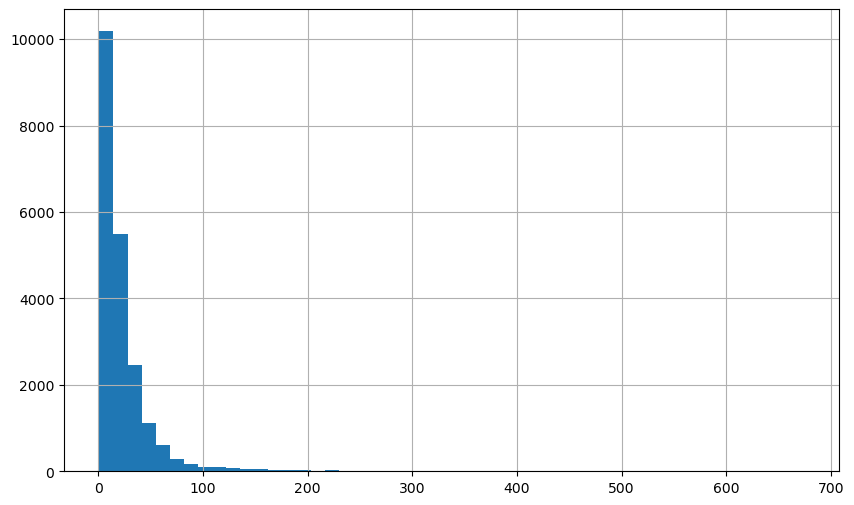

In [58]:
invoice_behaviour["unique_products"].hist(
    figsize=(10,6),
    bins=50
)

Some of the key findings about invoices in this dataset are: The cleaned dataset contains 20,951 invoices. The average invoice contains 23.8 unique products. The median invoice contains 15 unique products, so baskets with multiple produtcs are not only caused by a few extreme invoices. There are extreme outliers to be checked. 

89.82% of invoices contain more than one product. It means there's enough data to identify product relationships and generate upselling recommendations. The dataset is suitable for association rule mining and techniques like Apriori to build my basket algorithm. 

Next I'll perform country analysis. The goal is to understand how different countries affect customer segmentation and if it's proper for market basket analysis. 

In [61]:
countries_summary = df_clean.groupby("Country").agg(
    total_revenue=("Revenue", "sum"),
    total_quantity=("Quantity", "sum"),
    invoice_count=("Invoice", "nunique"),
    customer_count=("Customer ID", "nunique")
).sort_values(by="total_revenue", ascending=False)

countries_summary.head(10)

,total_revenue,total_quantity,invoice_count,customer_count
Country,,,,
United Kingdom,8812311.833,4702280,19290,3969
EIRE,380909.570,193047,348,5
Netherlands,268784.350,183615,135,22
Germany,202025.391,108615,347,67
France,147103.140,163029,241,47
Sweden,53501.990,52555,69,16
Denmark,50906.850,229690,26,9
Spain,47568.650,22841,66,25
Switzerland,43921.390,22255,40,14


UK seems to dominate the dataset, especially in terms of invoice. So I'll further investigate how dominant the UK actually is in the dataset. First I'll take the total ammount of revenue, invoice and customer count and then calculate in percentage how much of it comes from the UK.  

In [76]:
revenue_allCountries = countries_summary["total_revenue"].sum()
invoices_allCountries = countries_summary["invoice_count"].sum()
customers_allCountries = countries_summary["customer_count"].sum()

print("Revenue All Countries: ", revenue_allCountries)
print("Invoices All Countries: ", invoices_allCountries)
print("Customers All Countries: ", customers_allCountries)

Revenue All Countries:  10271762.664
Invoices All Countries:  20951
Customers All Countries:  4317


In [89]:
uk_revenue = (
    countries_summary.loc["United Kingdom", "total_revenue"] / revenue_allCountries
) * 100

uk_invoices = (
    countries_summary.loc["United Kingdom", "invoice_count"] / invoices_allCountries
) * 100

uk_customers = (
    countries_summary.loc["United Kingdom", "customer_count"] / customers_allCountries
) * 100

print("UK revenue percentage:", uk_revenue, "%")
print("UK invoice percentage:", uk_invoices, "%")
print("UK customer percentage:", uk_customers, "%")

UK revenue percentage: 85.79162234623064 %
UK invoice percentage: 92.07197747124243 %
UK customer percentage: 91.93884642112579 %


<Axes: title={'center': 'Top 10 Countries by Revenue'}, xlabel='Country'>

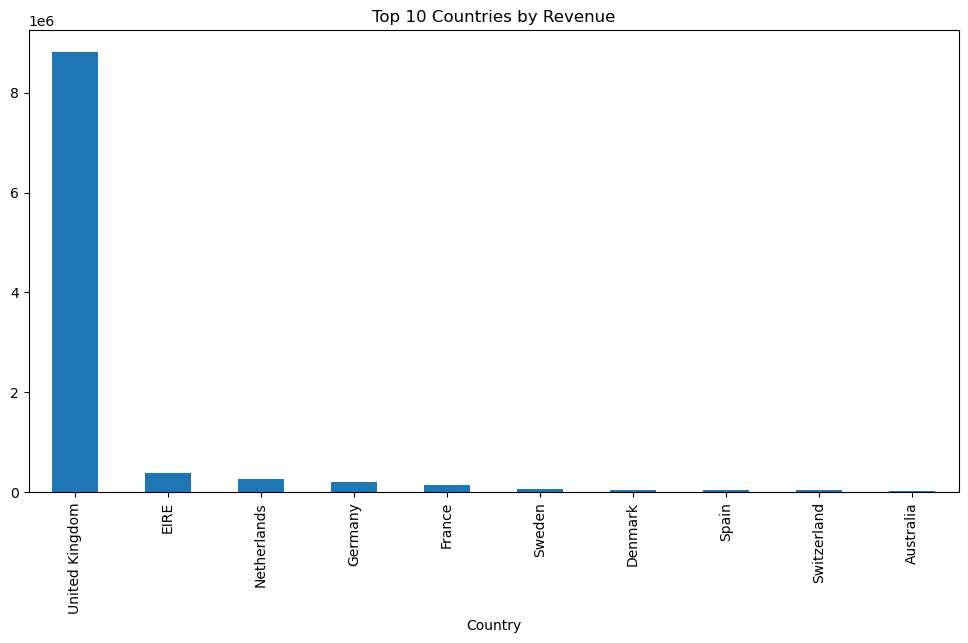

In [85]:
top_countries_revenue = countries_summary.sort_values(
    by="total_revenue",
    ascending=False
).head(10)

top_countries_revenue["total_revenue"].plot(
    kind="bar",
    figsize=(12,6),
    title="Top 10 Countries by Revenue"
)

<Axes: title={'center': 'Top 10 countries by Number of Invoices'}, xlabel='Country'>

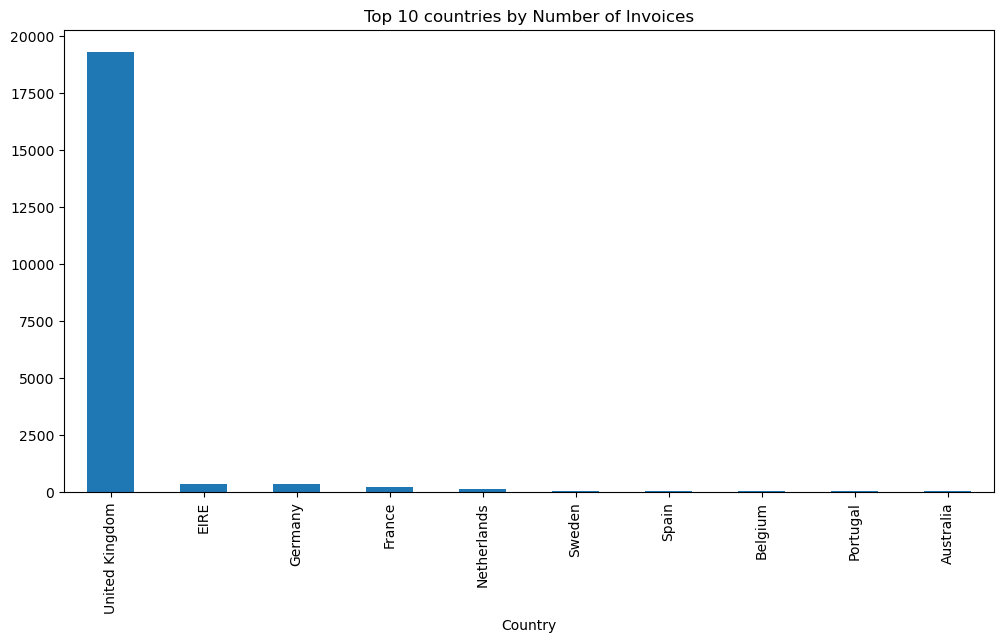

In [86]:
top_countries_invoices = countries_summary.sort_values(
    by="invoice_count",
    ascending=False
).head(10)

top_countries_invoices["invoice_count"].plot(
    kind="bar",
    figsize=(12,6),
    title="Top 10 countries by Number of Invoices"
)

The key findings of the Countries Analysis are: The UK heavily dominates the dataset with 85,79% of total revenue, 92,07% of invoices and 91,94% of identifiable customers. That means the UK is the main market in this dataset. The full dataset is useful for a more general exploratory analysis but I'll probably only use the UK market in later recommendation analysis to reduce imbalance and improve consistency of product association patterns. 

Next I'll check outliers and understand more of their relevance and impact in this dataset. The features to be inspected are: Revenue, Quantity, invoice values and customer total revenue. 

In [90]:
df_clean.sort_values(
    by="Revenue",
    ascending=False
).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
241827,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,25111.09
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.40
517955,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.50
135015,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,10953.50
342147,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,10468.80
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,10468.80
372834,525399,M,Manual,1,2010-10-05 11:49:00,10468.80,NaN,United Kingdom,10468.80
74356,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,8985.60
228042,511465,15044A,PINK PAPER PARASOL,3500,2010-06-08 12:59:00,2.55,18008.0,United Kingdom,8925.00


In [93]:
df_clean.sort_values(
    by="Quantity",
    ascending=False
).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
90857,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,2010-02-15 11:57:00,0.10,13902.0,Denmark,1915.2
127166,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,1296.0
127168,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,2010-03-17 13:09:00,0.10,13902.0,Denmark,1296.0
127169,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,2010-03-17 13:09:00,0.10,13902.0,Denmark,1274.4
127167,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,2010-03-17 13:09:00,0.10,13902.0,Denmark,1248.0
135028,502269,21982,PACK OF 12 SUKI TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0
135027,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0
135029,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0
135030,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0,United Kingdom,2500.0
93677,498152,85220,SMALL FAIRY CAKE FRIDGE MAGNETS,9456,2010-02-17 10:51:00,0.30,13902.0,Denmark,2836.8


In [95]:
invoice_behaviour.sort_values(
    by="invoice_value",
    ascending=False
).head(10)

,Invoice,invoice_value,total_quantity,unique_products,total_lines
18645,533027,49844.99,13387,111,111
17979,531516,45332.97,12410,115,115
1782,493819,44051.60,25018,94,94
14746,524181,33167.80,8172,13,13
16053,526934,26007.08,5079,15,15
9643,512771,25111.09,1,1,1
11010,515944,22863.36,4992,17,17
5520,503061,22853.77,5924,117,117
11826,517731,21984.00,4800,16,16
2488,495591,18570.88,12832,89,90


In [96]:
customer_behaviour.sort_values(
    by="total_revenue",
    ascending=False
).head(10)

,Customer ID,total_revenue,total_quantity,invoice_count,unique_products,average_order_values
4183,18102,349164.35,124216,89,281,556.880941
1637,14646,248396.50,170278,78,606,140.099549
1269,14156,196549.74,108105,102,1094,74.281837
1840,14911,152121.22,69709,205,1741,27.320621
939,13694,131443.19,125893,94,654,137.349206
3744,17511,84541.17,55107,31,423,89.178449
1951,15061,83284.38,51791,86,116,142.610240
3128,16684,80489.21,54555,27,124,182.515215
3177,16754,65500.07,63551,29,38,467.857643
4065,17949,60117.60,30112,74,34,691.006897


Key findings of the outliers analysis are: many extreme revenue rows are not normal products, they have M/Manual and AMAZONFEE that are not sold items. They should probably be excluded from product recommendation and basket analysis. 
There are also high quantites of bulk purchases. Some Invoices have very high value, quantity and product variety. Customer level behaviour is highly unequal. A small group of customers generates very high revenue and purchase volume. It supports customer segmentation. 
The conclusion is that these findings confirm that further preparation is required before modelling, especially excluding non-product codes from recommendation analysis and applying scaling or transformation before clustering.

I can conclude my EDA after this last analysis. So far I've checked the dataset structure, data quality, cleaning impact, time trend analysis, product performance, customer behaviour, basket suitability, country dominance and outlier inspection. That should be enough for me to write my Stage 2 CRISP-DM report on Data Understanding. 